## Portfolio Optimization

Portfolio optimization models are concerned with investment where there are typically two criteria: expected return and risk. The investor wants the former to be high and the latter to be low. There is a variety of measures
of risk. The most popular measure of risk has been variance in return. Even though there are some problems with it, we will first look at it very closely.

Some notations that will be heavily used later are:

* expected return:
$$ E(R_{p}) = \sum _{i}w_{i} E(R_{i}) $$ 
where $R_{p}$ is the return on the portfolio, $R_{i}$ is the return on asset $i$ and $w_{i}$ is the weighting of component asset $i$ (that is, the proportion of asset $i$ in the portfolio) and $\sum_{i}w_i = 1$ and $0 \le w_i \le 1$;
* portfolio return variance:
$$ \sigma _{p}^{2} = \sum _{i}w_{i}^{2}\sigma _{i}^{2} + \sum _{i}\sum _{j\neq i}w_{i}w_{j}\sigma _{i}\sigma _{j}\rho _{ij} $$
where $\sigma$ is the (sample) standard deviation of the periodic returns on an asset, and $\rho _{ij}$ is the correlation coefficient between the returns on assets $i$ and $j$. In a more compact way it can be expressed as:
$$ \sigma _{p}^{2}=\sum _{i}\sum _{j}w_{i}w_{j}\sigma _{ij} $$
where $\sigma _{ij}=\sigma _{i}\sigma _{j}\rho _{ij}$ is the (sample) covariance of the periodic returns on the two assets, or alternatively denoted as $\Sigma$, $\sigma (i,j)$, $cov_{ij}$ or $cov(i,j)$;
* portfolio return volatility (standard deviation):
$$ \sigma _{p}= \sqrt{\sigma _{p}^{2}}$$

### The Markowitz Mean/Variance Portfolio Model
The portfolio model, introduced by Markowitz, assumes an investor has two considerations when constructing an investment portfolio: expected return and variance in return (i.e., risk). Variance measures the variability in realized return around the expected return. Hence the Markowitz model requires two major kinds of information: 

* the estimated expected return for each candidate investment;
* the covariance matrix of returns. 

The covariance matrix characterizes not only the individual variability of the return on each investment, but also how each investment’s return tends to move with other investments. 

Part of the appeal of the Markowitz model is that it can be solved by efficient quadratic programming methods. Quadratic programming is the name applied to the class of models in which the objective function is a quadratic function and the constraints are linear. Thus, the objective function is allowed to have terms that are products of two variables such as $x^2$ and $x\cdot y$.

### Example
In the following example data from Quandl will be used. The following table shows part of the sample which include for each entry a date and the corresponding closing price of five company stocks: AAPL, AMZN, FB, GOOG, NFLX.

In [1]:
import pandas as pd

temp = pd.read_csv("quandl.csv")
clean = temp.set_index('date')
df = clean.pivot(columns='ticker')

print (df.head())

            adj_close                                
ticker           AAPL    AMZN      FB GOOG       NFLX
date                                                 
2014-01-02  73.523423  397.97  54.710  NaN  51.831429
2014-01-03  71.908415  396.44  54.557  NaN  51.871429
2014-01-06  72.300536  393.63  57.200  NaN  51.367143
2014-01-07  71.783135  398.03  57.920  NaN  48.500000
2014-01-08  72.238063  401.92  58.230  NaN  48.712857


With \texttt{pandas} the main characteristics of these time series can be easily computed (e.g. daily returns, covariance matrix):

In [2]:
# daily returns
daily_returns = df.pct_change()
print (daily_returns.head())
print ("Daily expected returns: ", daily_returns.mean())
annual_expected = daily_returns.mean() * 252
print ("Annual expected returns: ", annual_expected)

# covariance
covariance = daily_returns.cov()
print ("Daily covariance: ", covariance)

annual_covariance = covariance * 252
print ("Annual covariance: ", annual_covariance)

           adj_close                                   
ticker          AAPL      AMZN        FB GOOG      NFLX
date                                                   
2014-01-02       NaN       NaN       NaN  NaN       NaN
2014-01-03 -0.021966 -0.003845 -0.002797  NaN  0.000772
2014-01-06  0.005453 -0.007088  0.048445  NaN -0.009722
2014-01-07 -0.007156  0.011178  0.012587  NaN -0.055817
2014-01-08  0.006338  0.009773  0.005352  NaN  0.004389
Daily expected returns:             ticker
adj_close  AAPL      0.000882
           AMZN      0.001418
           FB        0.001115
           GOOG      0.000686
           NFLX      0.002008
dtype: float64
Annual expected returns:             ticker
adj_close  AAPL      0.222314
           AMZN      0.357435
           FB        0.281059
           GOOG      0.172818
           NFLX      0.505967
dtype: float64
Daily covariance:                   adj_close                                        
ticker                AAPL      AMZN        FB   

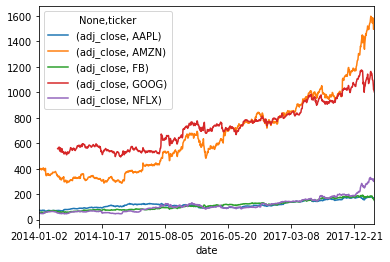

In [10]:
df.plot()

The correlation matrix makes it more obvious how two random variables move together. The correlation between two random variables equals the covariance between the two variables, divided by the product of the standard deviations of the two random variables. 
The correlation can be between -1 and +1 with +1 (-1) being perfect correlation (anticorrelation) between the two.

Simulating a large number of set of weights we can see which is the distribution of these portfolios in terms of return and volatility.

<img src="Figure_1.png">

### Optimization

Remembering that $w_i$ represents the fraction of the portfolio devoted to each stock (weights), Markowitz model states that these weights should be choosen such that the portfolio volatility (or its variance) is minimized. So the application of Markovitz model reduces to an optimization problem, given the covariance matrix of the portfolio $\sigma_p^2$ estimated before from the historical series:

$$ J = \textrm{min}(\sigma_p^2) $$

with the usual constraints $\sum_{i}w_i = 1$ and $0 \le w_i \le 1$.

In \texttt{python} we already know how to solve a minimization problem (see bootstrapping) so it is enough to repeat the same steps:

* define an objective function (in this case the variance of the portfolio);
* define a set of contraints;
* set an initial guess for the weights;
* pass everything to \texttt{scipy.optimize.minimize} algorithm.

In [4]:
import numpy as np, matplotlib.pyplot as plt, scipy.optimize as optimize

def sumWeights(weights):
    return np.sum(weights) - 1

def objective(weights, covariance):
    return np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))

numAssets = 5
constraints = ({'type': 'eq', 'fun': sumWeights},)
bounds = tuple((0, 1) for asset in range(numAssets))

opts = optimize.minimize(objective, np.ones(numAssets) / float(numAssets), args=(annual_covariance,),
                         bounds=bounds, constraints=constraints)

print ("Optimization results:\n", opts)

print ("\nRecommended weights: ", opts.x)
print ("Portfolio expected annual return: {:.4f}".format(np.sum(annual_expected*opts.x)))

Optimization results:
      fun: 0.18996519187658553
     jac: array([0.19007478, 0.19040664, 0.18950935, 0.1898793 , 0.18995349])
 message: 'Optimization terminated successfully.'
    nfev: 63
     nit: 9
    njev: 9
  status: 0
 success: True
       x: array([0.44735955, 0.06873074, 0.10429827, 0.36908076, 0.01053068])

Recommended weights:  [0.44735955 0.06873074 0.10429827 0.36908076 0.01053068]
Portfolio expected annual return: 0.2224


The solution recommends about 44\% of the portfolio be put in AAPL, about 7\% in AMZN, 10\% in FB and so on... 
The expected return is about 22\%, with a variance of 0.03 or, equivalently, a standard deviation of about 0.17.

In this example we based the model simply on straightforward statistical data derived from daily returns. 
However it could be possible, rather than use historical data for estimating the expected return of an asset, to base this estimate on more current, proprietary information about expected future performance of the asset.

### Efficient Frontier
There is no precise way for an investor to determine the “correct” working point between risk and return. For example if an investor wants a higher expected return, she generally has to “pay for it” with higher risk.
Thus, one is frequently interested in looking at the distribution of the tradeoff between the two.  In finance terminology, we would like to trace out the \emph{efficient frontier} of return and risk. This is doable solving for the minimum variance portfolio over a range of values for the expected return (e.g. ranging from 0.20 to 0.45).
Back to our example portfolio we get the following plot or tradeoff curve:

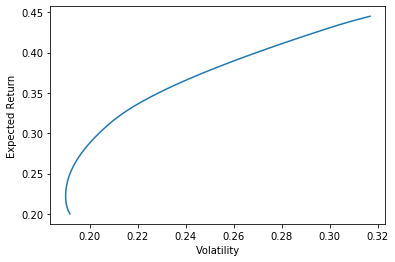

In [5]:
numAssets = 5

def getTargetReturn(weights, returns, targetReturn):
    portfolio_return = np.sum(returns*weights)
    return (portfolio_return - targetReturn)

returns = []
for eff in np.arange(0.20, 0.45, 0.005):
    # in this case there is tha usual constraint on the sum of the weights
    # PLUS the one that force the resulting return to be equal to the choosen target
    constraints = ({'type': 'eq', 'fun': getTargetReturn, "args":(annual_expected, eff,)},
                   {'type': 'eq', 'fun': sumWeights})
    bounds = tuple((0, 1) for asset in range(numAssets))
    opts = optimize.minimize(objective, np.ones(numAssets) / float(numAssets), args=(annual_covariance,),
                             bounds=bounds, constraints=constraints)

    returns.append((np.sqrt(np.dot(opts.x.T, np.dot(annual_covariance, opts.x))), np.sum(annual_expected*opts.x)))

#print (returns)
returns = np.array(returns)

plt.plot(returns[:,0], returns[:,1])
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.show()

### Portfolios with a Risk-Free Asset
When one of the investments available is risk free, then the efficient frontier has a
particularly simple form, a line called the capital allocation line (CAL). 
The slope of the CAL measures the trade-off between risk and return. A higher slope means that investors receive a higher expected return in exchange for taking on more risk. The value of this calculation is known as the Sharpe ratio.

The capital allocation line aids investors in choosing how much to invest in a risk-free asset and one or more risky assets. 

The simplest example is a portfolio containing two assets: a risk-free Treasury bill and a stock. Assume that the expected return of the Treasury bill is $R_f=3\%$ and its risk is 0\%. Further, assume that the expected return of the stock is $R_r=10\%$ and its standard deviation is $\sigma_r=20\%$. The question that needs to be answered for any individual investor is how much to invest in each of these assets. 

The expected return ($R_p$) of this portfolio is calculated as follows:

$$ R_p = R_f\cdot w_f + R_r\cdot (1- w_f) $$

where $w_f$ is the relative allocation to the risk-free asset. 

The calculation of risk for this portfolio is simple because the standard deviation of the Treasury bill is 0\%. Thus, risk is calculated as:

$$ \sigma_p = (1-w_f)\cdot \sigma_r $$

In this very simple example, if an investor were to invest 100\% into the risk-free asset ($w_f=1$), the expected return would be 3\% and the risk of the portfolio would be 0\%. Likewise, investing 100\% into the stock ($w_f=0$) would give an investor an expected return of 10\% and a portfolio risk of 20\%. If the investor allocated 25\% to the risk-free asset and 75\% to the risky asset, the portfolio expected return and risk calculations would be:

$$ R_p = (3\% \cdot 25\%) + (10\% \cdot 75\%) = 0.75\% + 7.5\% = 8.25\% $$

$$ \sigma_p = 75\% \cdot 20\% = 15\% $$

Applying the same reasoning to our example we can consider an additional risk-free asset with an expected return of 10\% and repeat the minimization to determine the effecient frontier of the resulting portfolio. Notice how the objective function is still the same, while the target return constraint now includes the risk-free asset.

[1.06162709e-01 3.00245096e-01 3.91027233e-02 1.86970665e-16
 2.77464263e-01 2.77025209e-01]
[0.11253273 0.31430908 0.0394508  0.         0.29110398 0.24260341]
[1.18236614e-01 3.29087208e-01 4.09557480e-02 3.38271078e-17
 3.03975578e-01 2.07744852e-01]
[1.23144777e-01 3.43589838e-01 4.32121687e-02 9.70360944e-18
 3.16926467e-01 1.73126749e-01]
[1.27609029e-01 3.57964675e-01 4.55916487e-02 4.04610698e-17
 3.30037256e-01 1.38797392e-01]
[0.13179514 0.37244133 0.04782824 0.         0.34323101 0.10470428]
[1.35740858e-01 3.87575537e-01 4.95277999e-02 1.08420217e-19
 3.56319729e-01 7.08360764e-02]
[0.13908026 0.4012752  0.05288889 0.         0.36975978 0.03699587]
[0.14341577 0.41615807 0.0531975  0.         0.38351079 0.00371787]
[0.1128041  0.43517892 0.04149147 0.         0.41052551 0.        ]


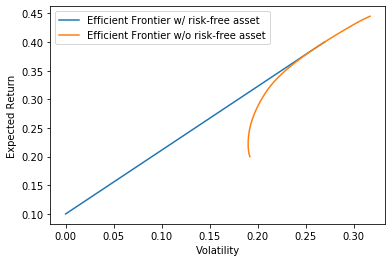

In [6]:
numAssets = 6

def sumWeights2(weights):
    return np.sum(weights) - 1

def objective4(weights, covariance):
    return np.sqrt(np.dot(weights[:-1].T, np.dot(covariance, weights[:-1])))

def getTargetReturn2(weights, returns, targetReturn, risk_free):
    portfolio_return = np.sum(returns*weights[:-1]) + (weights[5]) * risk_free
    return (portfolio_return - targetReturn)

rfAssetReturn = 0.10
returns2 = []
for eff in np.arange(0.10, 0.40, 0.01):
    #print (eff)
    # in this case there is tha usual constraint on the sum of the weights
    # PLUS the one that force the resulting return to be equal to the choosen target
    constraints = ({'type': 'eq', 'fun': getTargetReturn2, "args":(annual_expected, eff, rfAssetReturn)},
                   {'type': 'eq', 'fun': sumWeights2})
    bounds = tuple((0, 1) for asset in range(numAssets))
    opts = optimize.minimize(objective4, np.ones(numAssets) / float(numAssets), args=(annual_covariance),
                             bounds=bounds, constraints=constraints)
    if eff >= 0.3:
        print (opts.x)

    returns2.append((np.sqrt(np.dot(opts.x[:-1].T, np.dot(annual_covariance, opts.x[:-1]))), 
                    np.sum(annual_expected*opts.x[:-1])+opts.x[5]*rfAssetReturn))
#print (returns2)
returns2 = np.array(returns2)

plt.plot(returns2[:,0], returns2[:,1], label="Efficient Frontier w/ risk-free asset")
plt.plot(returns[:,0], returns[:,1], label="Efficient Frontier w/o risk-free asset")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.legend()
plt.show()

As it is clear from the plot the efficient frontier has become a straight line, tangent to the frontier of the risky assets only.
When the target is 10\% the entire investement is allocated to the risk-free asset, as the target increases the fraction of the risky assets grows proportionally to the volatilty. In general the relative proportions devoted to risky investments do not change. Only the allocation between the risk-free asset and the risky assets change.

### The Sharpe Ratio
For some portfolio $p$, of risky assets, excluding the risk-free asset, let it be:

* $R_p$ its expected return;
* $\sigma_p$ its standard deviation in return;
* $r_0$ the return of the risk-free asset.

A plausible single measure (as opposed to the two measures, risk and return) of attractiveness of
portfolio $p$ is the Sharpe ratio:

$$ \cfrac{R_p - r_0}{\sigma_p} $$

In words, it measures how much additional return we achieved for the additional risk we took on,
relative to putting all our money in the risk-free asset.
The portfolio that maximizes this ratio has a certain well-defined appeal. Suppose:

* $t$ our desired target return;
* $w_p$ the fraction of our wealth we place in portfolio $p$ (the rest placed in the risk-free asset).

To meet our return target, we must have:

$$ (1 - w_p) * r_0 + w_p * R_p = t $$

The standard deviation of our total investment is: $w_p\cdot \sigma_p$.
Solving for $w_p$ in the equation above, we get:

$$ w_p = \cfrac{t – r_0}{R_p – r_0} $$

Thus, the standard deviation of the portfolio is:

$$ w_p\cdot \sigma_p = \Big[\cfrac{t – r_0}{R_p – r_0}\Big]\cdot \sigma_p $$

Minimizing the portfolio standard deviation means:

$$ \textrm{min}\Big(\Big[\cfrac{t – r_0}{R_p – r_0}\Big]\cdot \sigma_p\Big)\implies\textrm{max}\Big(\cfrac{R_p – r_0}{\sigma_p}\Big) $$

So, regardless of our risk/return preference, the money we invest in risky assets should be invested
in the risky portfolio that maximizes the Sharpe ratio.

Let's see the application of the Sharpe ration on our sample:

Optimized weights:  [0.14534034 0.41720748 0.0539508  0.         0.38350138]
Sharpe ratio:  1.1137235916752375


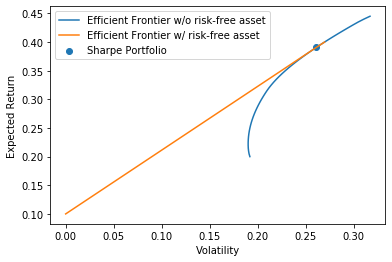

0.14684150855260944
0.41529123783157273
0.054085873768417794
2.5861297966392867e-16
0.3837813798473999


In [7]:
numAssets = 5
riskFreeRate = 0.10
args = (annual_expected, riskFreeRate, annual_covariance)

def negativeSharpeRatio(weights, annualReturns, riskFreeRate, annual_covariance):
    p_ret = np.sum(annualReturns*weights)
    p_var = np.sqrt(np.dot(weights.T, np.dot(annual_covariance, weights)))
    ratio = -(p_ret - riskFreeRate) / p_var
    return ratio
    
constraints = ({'type': 'eq', 'fun': sumWeights})
bounds = tuple((0, 1) for asset in range(numAssets))

opts = optimize.minimize(negativeSharpeRatio, np.ones(numAssets) / float(numAssets), args=args,
                         bounds=bounds, constraints=constraints)

print ("Optimized weights: ", opts.x)

ret = np.sum(annual_expected*opts.x)
vol = np.sqrt(np.dot(opts.x.T, np.dot(annual_covariance, opts.x)))

print ("Sharpe ratio: ", -opts.fun)

plt.plot(returns[:,0], returns[:,1], label="Efficient Frontier w/o risk-free asset")
plt.plot(returns2[:,0], returns2[:,1], label="Efficient Frontier w/ risk-free asset")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.scatter(vol, ret, label="Sharpe Portfolio")
plt.legend()
plt.show()
a = [1.06162709e-01, 3.00245096e-01, 3.91027233e-02, 1.86970665e-16, 2.77464263e-01]
for i in a:
    print (i/sum(a))

Notice that in general the relative proportions of the stocks are the same as in the previous case where we explicitly included a risk free asset (0.143, 0.416, 0.0532, 0., 0.383). 

So the optimization using the Sharpe ratio gives us a portfolio that is on the minimum volatility efficient frontier, and gives the maximum return relative to putting all our money in the risk-free asset.

What is considered a good Sharpe ratio that indicates a high degree of expected return for a relatively low amount of risk?
Usually, any Sharpe ratio greater than 1.0 is considered acceptable to good by investors. A ratio higher than 2.0 is rated as very good. A ratio of 3.0 or higher is considered excellent. A ratio under 1.0 is considered sub-optimal.

### Limits of the Markowitz Model

Despite the significant utility of the Markowitz theory, there are some major limitations in this model:

* it is difficult to forecast asset returns with accuracy using historical data, which tends to be a poor forecasting source. As return estimations have a much larger impact on the asset allocations, small changes in return assumptions can lead to inefficient portfolios. Therefore, the model tends to lead to highly concentrated portfolios (out-of sample weights) that do not offer as much diversification benefits in practice as they seem to provide in theory;
* the model assumes that asset correlations are linear. In reality, asset correlations move dynamically, changing with the market cycles. During the global financial crisis, asset correlations approached almost 1, so if anything, diversification seemed to have insignificant impacts on the portfolios;
* last but not the least, the model assumes normality in return distributions. Therefore, it does not factor in extreme market moves which tend to make returns distributions either skewed, fat tailed or both. Without optimizing the portfolio for asset that may actually have skewed distributions or fat tailed, it could lead to a riskier allocation that is intended.

## Risk Parity Portfolio

An alternative approach to Markowitz theory is given by the \emph{risk parity}. A risk parity portfolio is an investment allocation strategy which focuses on the allocation of risk, rather than the allocation of capital. 
A risk parity (equal risk) portfolio is characterized by having equal risk contributions to the total risk from each individual asset. For example, a typical 40\% bond 60\% equity portfolio has a significant risk in equity, allocation according to the risk parity principle would lead to same risk contribution between equity and bond.

Risk parity allocation is also referred to as equally-weighted risk contributions portfolio method.
Equally-weighted risk contributions is not about \emph{having the same volatility}, it is about having each asset contributing in the same way to the portfolio overall volatility. For this we will have to define the contribution of each asset to the portfolio risk.
This allocation strategy has gained popularity in the last decades since it is believed to provide better risk adjusted return than capital based allocation strategies.

Let's go over a very basic example to better illustrate how to construct a simple risk parity (equal risk) portfolio. Later we will see how easy is to extend this technique to a risk budgeting portfolio (targeted risk allocation).

Consider a portfolio of $N$ assets: $x_{1}, \ldots, x_N$ where as usual the weight of the asset $x_{i}$ is denoted by $w_{i}$. The $w_{i}$ form the allocation vector $\mathbf{w}$. Let us further denote the covariance matrix of the assets as $\Sigma$. The volatility of the portfolio is then defined as:

$$ \sigma_p={\sqrt {\mathbf{w^T}\Sigma \mathbf{w}}} = \sum _{i=1}^{N}\sigma _{i} $$

where $\sigma _{i} = w_{i}\cdot \cfrac{\partial\sigma_p}{\partial w_{i}}={\cfrac {w_{i}(\Sigma \mathbf{w})_{i}}{\sqrt {\mathbf{w^T}\Sigma \mathbf{w}}}}$ so that $\sigma _{i}$ can be interpreted as the contribution of asset $i$ in the portfolio to the overall risk of the portfolio.

Equal risk contribution then means $\sigma _{i} =\sigma _{j}$ for all $i,j$ or equivalently $\sigma _{i}=\sigma_p/N$.

The solution for the weights can be found by solving the minimization problem:

$$ \underset{w}{\arg \min } \sum _{i=1}^{N}\left[w_{i}-{\frac {\sigma_p^{2}}{(\Sigma \mathbf{w})_{i}N}}\right]^{2} $$

Going back to our data sample let's find out the weights to give us a risk parity portfolio:

In [8]:
def objective2(weights, annual_covariance):
    variance = np.dot(weights.T, np.dot(annual_covariance, weights))
    sum = 0
    N = len(weights)
    for i in range(N):
        sum += (weights[i] - (variance/(N*np.dot(annual_covariance, weights)[i])))**2
        
    return sum

numAssets = 5
args = (annual_covariance,)

constraints = ({'type': 'eq', 'fun': sumWeights})
bounds = tuple((0, 1) for asset in range(numAssets))

opts = optimize.minimize(objective2, np.ones(numAssets) / float(numAssets), args=args,
                         bounds=bounds, constraints=constraints)
print (opts)  

sigma_i = []
for i in range(numAssets):
    std = np.sqrt(np.dot(opts.x.T, np.dot(annual_covariance, opts.x)))
    a = opts.x[i]*np.dot(annual_covariance, opts.x)[i]
    sigma_i.append(a/std)

for i in range(numAssets):
    print ("Risk contribution for asset {}: {:.1f}".format(i, sigma_i[i]/sum(sigma_i)*100))

     fun: 4.346493043692613e-09
     jac: array([-1.23266291e-03,  2.57970389e-04,  1.45282552e-04,  8.26707332e-06,
        1.75063489e-03])
 message: 'Optimization terminated successfully.'
    nfev: 39
     nit: 5
    njev: 5
  status: 0
 success: True
       x: array([0.26364018, 0.18110151, 0.19069323, 0.22253642, 0.14202866])
Risk contribution for asset 0: 20.0
Risk contribution for asset 1: 20.0
Risk contribution for asset 2: 20.0
Risk contribution for asset 3: 20.0
Risk contribution for asset 4: 20.0


### Risk budget allocation

The same technique can be used if we would like to calculate a portfolio with risk budget allocation. If we consider the previous equation:

$$ \sigma _{i}=\cfrac{\sigma_p}{N} $$

where we set the risk contribution fraction to every asset to $1/N$; now we can simply replace $1/N$ with the desired  fraction ($f_i$) for each asset:

$$ \sigma _{i}=f_i \cdot \sigma_p $$

so that the relation to minimize becomes:

$$ \underset{w}{\arg \min } \sum _{i=1}^{N}\left[w_{i}-{\frac {f_i \cdot \sigma_p^{2}}{(\Sigma \mathbf{w})_{i}}}\right]^{2} $$

Translating it to \texttt{python} we get:

In [9]:
def objective3(weights, target_risk, annual_covariance):
    variance = np.dot(weights.T, np.dot(annual_covariance, weights))
    sum = 0
    N = len(weights)
    for i in range(N):
        sum += (weights[i] - ((target_risk[i]*variance)/(np.dot(annual_covariance, weights)[i])))**2
        
    return sum

f_i = [0.3, 0.2, 0.2, 0.15, 0.15]
numAssets = 5
args = (f_i, annual_covariance)

constraints = ({'type': 'eq', 'fun': sumWeights})
bounds = tuple((0, 1) for asset in range(numAssets))

opts = optimize.minimize(objective3, np.ones(numAssets) / float(numAssets), args=args,
                         bounds=bounds, constraints=constraints)
print (opts)  

sigma_i = []
for i in range(numAssets):
    std = np.sqrt(np.dot(opts.x.T, np.dot(annual_covariance, opts.x)))
    a = opts.x[i]*np.dot(annual_covariance, opts.x)[i]
    sigma_i.append(a/std)

for i in range(numAssets):
    print ("Risk contribution for asset {}: {:.1f}".format(i, sigma_i[i]/sum(sigma_i)*100))

     fun: 3.985449091312236e-07
     jac: array([-0.00090474,  0.00038776,  0.0009308 , -0.00032641,  0.0011355 ])
 message: 'Optimization terminated successfully.'
    nfev: 45
     nit: 6
    njev: 6
  status: 0
 success: True
       x: array([0.35019494, 0.17972679, 0.18831561, 0.16913951, 0.11262315])
Risk contribution for asset 0: 30.0
Risk contribution for asset 1: 20.0
Risk contribution for asset 2: 20.0
Risk contribution for asset 3: 15.0
Risk contribution for asset 4: 15.0


And indeed for each we have allocated the desired amount of risk.